## Mediocre ML Model for Humanity Score

In [45]:
import numpy as np
import pandas as pd
from keras.models import Sequential
from keras.layers import Dense
from keras.layers import LSTM
from keras.layers import Normalization
import os
import json

### Web Bot Dataset Loading

### Phase 2

In [ ]:
import os
import json

DATA_DIR = "./web_bot_detection_dataset"
PHASE2_DIR = os.path.join(DATA_DIR, "phase2/data/mouse_movements")
INFO_FILENAME = "humans_and_advanced_bots"
INFO_FILE = os.path.join(DATA_DIR, f"phase2/annotations/{INFO_FILENAME}/{INFO_FILENAME}")

def convert_datum(datum):
    datum = datum.replace('[', '').replace(']', '')
    pairs = [tuple(map(int, p.strip('()').split(','))) for p in datum.split(')(')]   
    return pairs 

def load_dataset(dir, info_file):
    links = {}
    with open(info_file, 'r') as f:
        for line in f:
            # print(line, type(line))
            id, label = line.split()
            if label not in links:
                links[label] = []
            links[label].append(id)

    print(links)
    
    human_dir = os.path.join(dir, "humans")
    human_data = []
    for file in os.listdir(human_dir):
        with open(os.path.join(human_dir, file), 'r') as f:
            for line in f:
                dct = json.loads(line)
                datum = dct['mousemove_client_height_width']
                human_data.append(convert_datum(datum))

    bot_dir = os.path.join(dir, "bots")
    bot_data = []
    for file in os.listdir(bot_dir):
        # n = 0
        print(file)
        with open(os.path.join(bot_dir, file), 'r') as f:
            for line in f:
                # if n == 30:
                #     break
                # n += 1
                dct = json.loads(line)
                datum = dct['mousemove_client_height_width']
                bot_data.append(convert_datum(datum))
        break

    return human_data, bot_data
    
human_data, bot_data = load_dataset(PHASE2_DIR)

len(human_data), len(bot_data)

mouse_movements_advanced_bots.json


(59, 120)

In [49]:
import numpy as np

SEG_LEN = 100

def segment_sessions(dataset, seg_len=SEG_LEN, stride=None):
    """
    Convert sessions into fixed-length segments.

    Args:
        dataset: dict {user: [session_arrays]}
        seg_len: length of each segment (default=100)
        stride: step size (default = seg_len, i.e., no overlap)

    Returns:
        segments: list of np.array (seg_len, 2)
        labels: list of user labels
    """
    if stride is None:
        stride = seg_len  # non-overlapping

    segments = []
    sessions = dataset
    
    if 1:
        for session in sessions:
            n = len(session)

            # Slide window
            for start in range(0, n - seg_len + 1, stride):
                seg = session[start:start + seg_len]

                if len(seg) == seg_len:
                    segments.append(seg)

    return np.array(segments, dtype=np.float32)

human_np = segment_sessions(human_data)
bot_np = segment_sessions(bot_data)
human_np.shape, bot_np.shape

((6219, 100, 2), (11702, 100, 2))

In [50]:
human_labels, bot_labels = np.zeros((human_np.shape[0],)), np.ones((bot_np.shape[0],))
human_labels.shape, bot_labels.shape

((6219,), (11702,))

In [51]:
x_train_set = np.concat([human_np, bot_np])
y_train_set = np.concat([human_labels, bot_labels])
x_train_set.shape, y_train_set.shape

((17921, 100, 2), (17921,))

In [52]:
from sklearn.model_selection import train_test_split

x_train, x_test, y_train, y_test = train_test_split(
    x_train_set, y_train_set, test_size=0.3, random_state=42, shuffle=True
)

In [ ]:
from sklearn.model_selection import train_test_split

x_train, x_test, y_train, y_test = train_test_split(
    x_train_set, y_train_set, test_size=0.3, random_state=42, shuffle=True
)

### Training

In [ ]:
import tensorflow as tf

file = "models/big_model.keras"
model = tf.keras.models.load_model(file)
# model.summary()

In [ ]:
import numpy as np
from keras.preprocessing.sequence import pad_sequences

SEG_LEN = 100

def segment_and_pad_sessions(dataset, seg_len=SEG_LEN, stride=None, n_max=None):
    """
    Groups segments by session, flattens segments to 200 features, 
    and pads to (N, n_max, 200).
    """
    if stride is None:
        stride = seg_len

    all_sessions_as_sequences = []
    labels = []
    
    for label_str, sessions in dataset.items():
        for session in sessions:
            n_points = len(session)
            session_segments = []

            # 1. Slice session into segments
            for start in range(0, n_points - seg_len + 1, stride):
                seg = session[start:start + seg_len] # Shape: (100, 2)
                
                if len(seg) == seg_len:
                    # 2. Flatten (100, 2) -> (200,)
                    session_segments.append(np.array(seg).flatten())

            # Only add sessions that actually have at least one segment
            if len(session_segments) > 0:
                all_sessions_as_sequences.append(np.array(session_segments))
                labels.append(0 if label_str == "human" else 1)

    # 3. Padding
    # This turns a list of [ (n1, 200), (n2, 200), ... ] into (N, n_max, 200)
    # If n_max is None, it will automatically use the length of the longest session
    padded_x = pad_sequences(
        all_sessions_as_sequences, 
        maxlen=n_max, 
        dtype='float32', 
        padding='post', 
        value=0.0
    )

    return padded_x, np.array(labels, dtype=np.int8)

# --- Usage ---
# You can specify n_max (e.g., 50) or let it auto-detect the maximum sessions have
x_train, y_train = segment_and_pad_sessions(total_train_data['humans_and_advanced_bots'])
x_test, y_test = segment_and_pad_sessions(total_test_data['humans_and_advanced_bots'], n_max=x_train.shape[1])

print(f"Train shape: {x_train.shape}") # (N, n_max, 200)
print(f"Labels shape: {y_train.shape}") # (N,)


import tensorflow as tf
from keras import layers, models
from keras.optimizers import Adam
from keras.callbacks import EarlyStopping

early_stop = EarlyStopping(
    monitor='val_loss',      # metric to monitor
    patience=10,              # epochs to wait before stopping
    restore_best_weights=True
)

# Parameters
max_n = None # 'None' allows for variable length during inference
features = 100 * 2 # Flattening your 100x2 matrix

model = models.Sequential([
    # 1. Masking layer: ignores timesteps that are all zeros (padding)
    layers.Masking(mask_value=0.0, input_shape=(max_n, features)),
    
    # 2. LSTM layers
    layers.LSTM(100, return_sequences=True, activation="relu"),
    layers.LSTM(200, return_sequences=False, activation="relu"), # Many-to-One: captures sequence intent
    
    # 3. Output Head
    layers.Dense(128, activation='relu'),
    layers.Dense(64, activation="relu"),
    layers.Dense(1, activation="sigmoid")
])

verbose, epochs, batch_size = 2, 50, 64
model.compile(
    optimizer=Adam(learning_rate=1e-4), 
    loss=keras.losses.BinaryFocalCrossentropy(),
    metrics=['accuracy']
)

model.fit(x_train, y_train, epochs=epochs, batch_size=batch_size, verbose=verbose,
          validation_data=(x_test, y_test), callbacks=(early_stop,))

_, accuracy = model.evaluate(x_test, y_test, batch_size=128, verbose=0)
print(f"Testing: {accuracy:.2%}")

In [33]:
import keras
from keras.optimizers import Adam
from keras.callbacks import EarlyStopping

early_stop = EarlyStopping(
    monitor='val_loss',      # metric to monitor
    patience=20,              # epochs to wait before stopping
    restore_best_weights=True
)

def lr_scheduler(epoch, lr):
    if epoch < 5:
        return lr
    elif epoch < 20:
        return 1e-4
    elif epoch < 40:
        return 1e-5
    else:
        return 1e-6   # lr * tf.math.exp(-0.1) # Exponential decay after 5 epochs

lr_callback = tf.keras.callbacks.LearningRateScheduler(lr_scheduler, verbose=1)

verbose, epochs, batch_size = 2, 40, 64
model.compile(
    optimizer=Adam(learning_rate=1e-3), 
    loss=keras.losses.BinaryFocalCrossentropy(),
    metrics=['accuracy']
)

model.fit(x_train, y_train, epochs=epochs, batch_size=batch_size, verbose=verbose,
          validation_data=(x_test, y_test), callbacks=(early_stop, lr_callback))

_, accuracy = model.evaluate(x_test, y_test, batch_size=128, verbose=0)
print(f"Testing: {accuracy:.2%}")


Epoch 1: LearningRateScheduler setting learning rate to 0.0010000000474974513.
Epoch 1/40
97/97 - 28s - 287ms/step - accuracy: 0.6610 - loss: 0.1692 - val_accuracy: 0.6700 - val_loss: 0.1495 - learning_rate: 0.0010

Epoch 2: LearningRateScheduler setting learning rate to 0.0010000000474974513.
Epoch 2/40
97/97 - 50s - 519ms/step - accuracy: 0.7091 - loss: 0.1412 - val_accuracy: 0.6285 - val_loss: 0.1606 - learning_rate: 0.0010

Epoch 3: LearningRateScheduler setting learning rate to 0.0010000000474974513.
Epoch 3/40
97/97 - 35s - 358ms/step - accuracy: 0.7236 - loss: 0.1333 - val_accuracy: 0.6489 - val_loss: 0.1597 - learning_rate: 0.0010

Epoch 4: LearningRateScheduler setting learning rate to 0.0010000000474974513.
Epoch 4/40
97/97 - 22s - 223ms/step - accuracy: 0.7315 - loss: 0.1332 - val_accuracy: 0.7104 - val_loss: 0.1366 - learning_rate: 0.0010

Epoch 5: LearningRateScheduler setting learning rate to 0.0010000000474974513.
Epoch 5/40
97/97 - 36s - 371ms/step - accuracy: 0.7413 -

In [42]:
def segment_session(session, label, seg_len=100, stride=None):
    segments = []
    if 1:   # for label, sessions in dataset.items():
        if 1: # sessions -> session
            n = len(session)
            # Slide window
            for start in range(0, n - seg_len + 1, stride):
                seg = session[start:start + seg_len]
                if len(seg) == seg_len:
                    segments.append(seg)
                else:
                    seg = seg + [seg[-1]] * (seg_len - len(seg))
                    segments.append(seg)
    label = 0 if label == "human" else 1
    return np.array(segments, dtype=np.float32), np.array(label, dtype=np.int8)

y_actuals, y_preds = [], []

for label, sessions in total_test_data['humans_and_advanced_bots'].items():
    for session in sessions:
        x_session, y_label = segment_session(session, label, stride=100)
        y_hats = model(x_session)
        y_pred = 0 if np.array(y_hats).mean() < 0.5 else 1
        y_actuals.append(y_label)
        y_preds.append(y_pred)

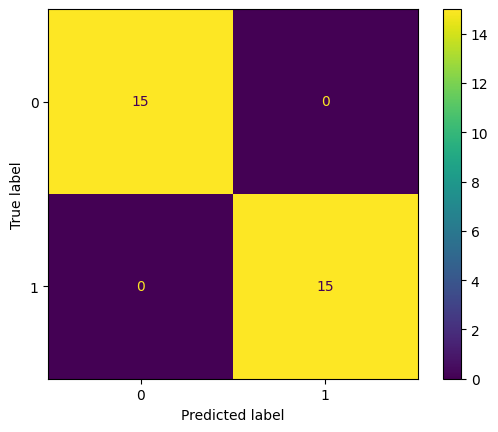

In [43]:
import numpy as np
from sklearn.metrics import ConfusionMatrixDisplay

y_actuals, y_preds = np.array(y_actuals), np.array(y_preds)

ConfusionMatrixDisplay.from_predictions(y_actuals, y_preds)

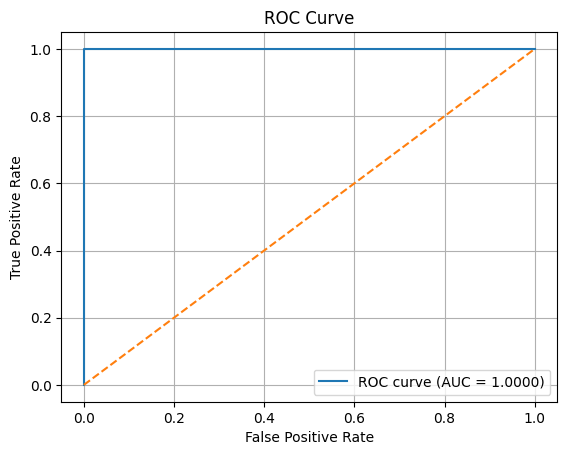

In [44]:
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc

y_scores = y_preds
fpr, tpr, thresholds = roc_curve(y_actuals, y_scores)
roc_auc = auc(fpr, tpr)
# Plot
plt.figure()
plt.plot(fpr, tpr, label=f"ROC curve (AUC = {roc_auc:.4f})")
plt.plot([0, 1], [0, 1], linestyle="--")  # random classifier line
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend(loc="lower right")
plt.grid(True)
plt.show()

In [ ]:
# _, accuracy = model.evaluate(human_np, human_labels, batch_size=128, verbose=0)
# print(f"Human Testing: {accuracy:.2%}")

# _, accuracy = model.evaluate(bot_np, bot_labels, batch_size=128, verbose=0)
# print(f"Bot Testing: {accuracy:.2%}")

(2260, 100, 2) (2260,)
71/71 ━━━━━━━━━━━━━━━━━━━━ 4s 58ms/step


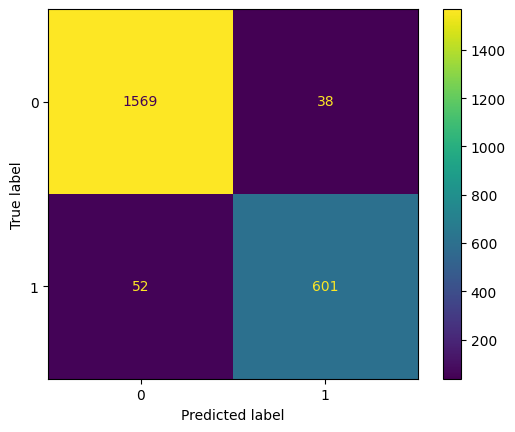

In [8]:
import numpy as np
from sklearn.metrics import ConfusionMatrixDisplay

y = y_test
x = x_test

print(x.shape, y.shape)

ConfusionMatrixDisplay.from_predictions(y, np.round(model.predict(x)))

71/71 ━━━━━━━━━━━━━━━━━━━━ 4s 56ms/step


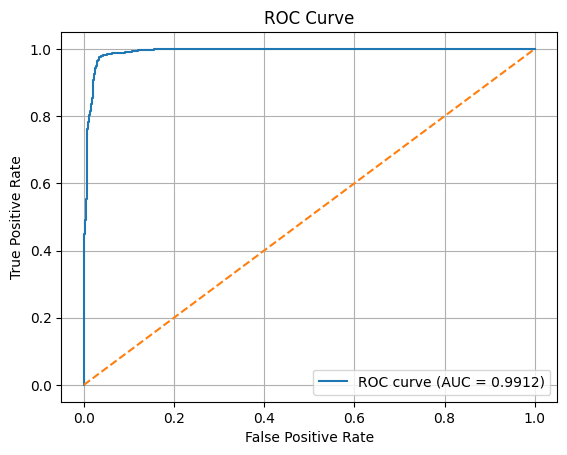

In [9]:
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc

x, y = x_test, y_test
y_scores = model.predict(x)  
fpr, tpr, thresholds = roc_curve(y, y_scores)
roc_auc = auc(fpr, tpr)
# Plot
plt.figure()
plt.plot(fpr, tpr, label=f"ROC curve (AUC = {roc_auc:.4f})")
plt.plot([0, 1], [0, 1], linestyle="--")  # random classifier line
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend(loc="lower right")
plt.grid(True)
plt.show()

In [17]:
tpr

array([0.00000000e+00, 6.87757909e-04, 3.43878955e-03, 5.50206327e-03,
       8.25309491e-03, 1.51306740e-02, 1.65061898e-02, 1.92572215e-02,
       2.20082531e-02, 2.47592847e-02, 2.61348006e-02, 3.30123796e-02,
       3.57634113e-02, 3.98899587e-02, 4.12654746e-02, 4.33287483e-02,
       2.59972490e-01, 2.76478680e-01, 2.78541953e-01, 2.79917469e-01,
       2.84731774e-01, 3.24621733e-01, 1.00000000e+00, 1.00000000e+00,
       1.00000000e+00, 1.00000000e+00, 1.00000000e+00, 1.00000000e+00,
       1.00000000e+00, 1.00000000e+00, 1.00000000e+00, 1.00000000e+00,
       1.00000000e+00, 1.00000000e+00, 1.00000000e+00, 1.00000000e+00,
       1.00000000e+00, 1.00000000e+00, 1.00000000e+00, 1.00000000e+00,
       1.00000000e+00, 1.00000000e+00, 1.00000000e+00, 1.00000000e+00,
       1.00000000e+00, 1.00000000e+00, 1.00000000e+00, 1.00000000e+00,
       1.00000000e+00, 1.00000000e+00, 1.00000000e+00, 1.00000000e+00,
       1.00000000e+00, 1.00000000e+00, 1.00000000e+00, 1.00000000e+00,
      

In [7]:
_, accuracy = model.evaluate(x_train_set, y_train_set, batch_size=128, verbose=0)
print(f"Testing: {accuracy:.2%}")

Testing: 24.45%


In [ ]:
import keras
from keras.optimizers import Adam

verbose, epochs, batch_size = 2, 10, 64
model.compile(
    optimizer=Adam(learning_rate=1e-4), 
    loss=keras.losses.BinaryFocalCrossentropy(),
    metrics=['accuracy']
)
# model.compile(loss='binary_crossentropy', optimizer='adam', metrics=['accuracy'])
model.fit(balabit_x_train, balabit_y_train, epochs=epochs, batch_size=batch_size, verbose=verbose)

In [11]:
_, accuracy = model.evaluate(balabit_x_test, balabit_y_test, batch_size=128, verbose=0)
print(f"Testing: {accuracy:.2%}")

Testing: 89.25%


In [12]:
full_train_x, full_test_x, full_train_y, full_test_y = np.concat([balabit_x_train, x_train]), np.concat([balabit_x_test, x_test]), np.concat([balabit_y_train, Y_train]), np.concat([balabit_y_test, Y_test])
full_train_x.shape, full_test_x.shape, full_train_y.shape, full_test_y.shape

((19292, 100, 2), (19627, 100, 2), (19292,), (19627,))

In [23]:
import keras
from keras.optimizers import Adam
from keras.callbacks import EarlyStopping

early_stop = EarlyStopping(
    monitor='val_loss',      # metric to monitor
    patience=3,              # epochs to wait before stopping
    restore_best_weights=True
)

verbose, epochs, batch_size = 2, 10, 64
model.compile(
    optimizer=Adam(learning_rate=1e-4), 
    loss=keras.losses.BinaryFocalCrossentropy(),
    metrics=['accuracy']
)
# model.compile(loss='binary_crossentropy', optimizer='adam', metrics=['accuracy'])
model.fit(full_train_x, full_train_y, epochs=epochs, batch_size=batch_size, verbose=verbose,
          validation_data=(full_test_x, full_test_y), callbacks=[early_stop])

Epoch 1/10
302/302 - 175s - 581ms/step - accuracy: 0.9930 - loss: 0.0097 - val_accuracy: 0.9944 - val_loss: 0.0084
Epoch 2/10
302/302 - 156s - 516ms/step - accuracy: 0.9979 - loss: 0.0021 - val_accuracy: 0.9947 - val_loss: 0.0097
Epoch 3/10
302/302 - 169s - 559ms/step - accuracy: 0.9985 - loss: 0.0014 - val_accuracy: 0.9949 - val_loss: 0.0105
Epoch 4/10
302/302 - 186s - 616ms/step - accuracy: 0.9991 - loss: 7.2941e-04 - val_accuracy: 0.9951 - val_loss: 0.0091


In [24]:
_, accuracy = model.evaluate(full_test_x, full_test_y, batch_size=128, verbose=0)
print(f"Full Testing: {accuracy:.2%}")

Full Testing: 99.44%


In [25]:
_, accuracy = model.evaluate(balabit_x_test, balabit_y_test, batch_size=128, verbose=0)
print(f"Balabit Testing: {accuracy:.2%}")

Balabit Testing: 99.92%


In [26]:
# Evaluate model
batch_size = 128

_, accuracy = model.evaluate(x_train, Y_train, batch_size=batch_size, verbose=0)
print(f"My Training: {accuracy:.2%}")

_, accuracy = model.evaluate(x_test, Y_test, batch_size=batch_size, verbose=0)
print(f"My Testing: {accuracy:.2%}")

My Training: 76.99%
My Testing: 66.43%


In [ ]:
# Evaluate model
batch_size = 128

_, accuracy = model.evaluate(x_train, Y_train, batch_size=batch_size, verbose=0)
print(f"My Training: {accuracy:.2%}")

_, accuracy = model.evaluate(x_test, Y_test, batch_size=batch_size, verbose=0)
print(f"My Testing: {accuracy:.2%}")

My Training: 76.99%
My Testing: 66.43%


In [ ]:
# Evaluate model
batch_size = 128

_, accuracy = model.evaluate(x_train, Y_train, batch_size=batch_size, verbose=0)
print(f"My Training: {accuracy:.2%}")

_, accuracy = model.evaluate(x_test, Y_test, batch_size=batch_size, verbose=0)
print(f"My Testing: {accuracy:.2%}")

My Training: 76.99%
My Testing: 66.43%


In [36]:
import tensorflow as tf
file = "models/big_model.keras"
model = tf.keras.models.load_model(file)
model.summary()

Model: "sequential_9"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_15 (LSTM)                  │ (None, 100, 200)       │       162,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_16 (LSTM)                  │ (None, 100)            │       120,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_16 (Dense)                │ (None, 128)            │        12,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_17 (Dense)                │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_18 (Dense)                │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 912,149 (3.48 MB)

 Trainable params: 304,049 (1.16 MB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 608,100 (2.32 MB)

In [23]:
import keras
from keras.optimizers import Adam

verbose, epochs, batch_size = 2, 10, 64

# To change both the optimizer and learning rate
model.compile(
    optimizer=Adam(learning_rate=1e-4), 
    loss=keras.losses.BinaryFocalCrossentropy(),
    metrics=['accuracy']
)

# model.compile(loss='binary_crossentropy', optimizer='adam', metrics=['accuracy'])

model.fit(x_train, Y_train, epochs=epochs, batch_size=batch_size, verbose=verbose)

# Evaluate model
_, accuracy = model.evaluate(x_train, Y_train, batch_size=batch_size, verbose=0)
print(f"Training: {accuracy:.2%}")

_, accuracy = model.evaluate(x_test, Y_test, batch_size=batch_size, verbose=0)
print(f"Testing: {accuracy:.2%}")

Epoch 1/10
4/4 - 3s - 664ms/step - accuracy: 0.9791 - loss: 0.0310
Epoch 2/10
4/4 - 1s - 149ms/step - accuracy: 0.9791 - loss: 0.0267
Epoch 3/10
4/4 - 1s - 159ms/step - accuracy: 0.9833 - loss: 0.0107
Epoch 4/10
4/4 - 1s - 154ms/step - accuracy: 0.9958 - loss: 0.0063
Epoch 5/10
4/4 - 1s - 175ms/step - accuracy: 0.9874 - loss: 0.0098
Epoch 6/10
4/4 - 1s - 175ms/step - accuracy: 0.9916 - loss: 0.0059
Epoch 7/10
4/4 - 1s - 181ms/step - accuracy: 0.9958 - loss: 0.0039
Epoch 8/10
4/4 - 1s - 182ms/step - accuracy: 0.9958 - loss: 0.0034
Epoch 9/10
4/4 - 1s - 189ms/step - accuracy: 0.9958 - loss: 0.0030
Epoch 10/10
4/4 - 1s - 196ms/step - accuracy: 0.9958 - loss: 0.0026
Training: 99.58%
Testing: 85.16%


(219, 100, 2) (219,)
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 72ms/step


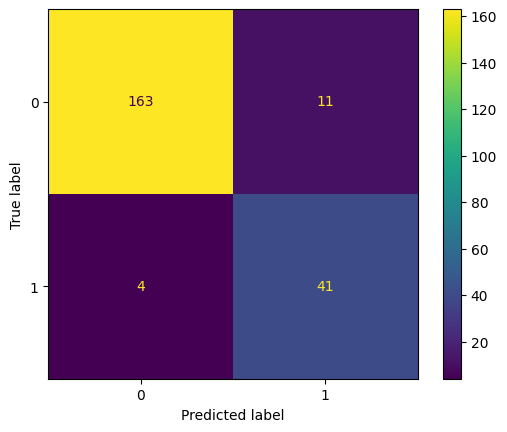

In [18]:
import numpy as np
from sklearn.metrics import ConfusionMatrixDisplay

id = 4

idx = np.concatenate((np.where(y_test == 0), np.where(y_test == id)), axis=1)

x = x_test[idx].squeeze()
y = y_test[idx].squeeze()

y = np.where(y==id, 1, y)

print(x.shape, y.shape)

ConfusionMatrixDisplay.from_predictions(y, np.round(model.predict(x)))

614/614 ━━━━━━━━━━━━━━━━━━━━ 22s 35ms/step


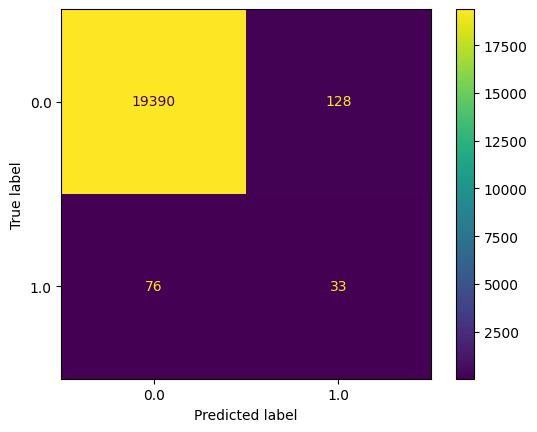

In [52]:
from sklearn.metrics import ConfusionMatrixDisplay

ConfusionMatrixDisplay.from_predictions(full_test_y, np.round(model.predict(full_test_x)))

9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step


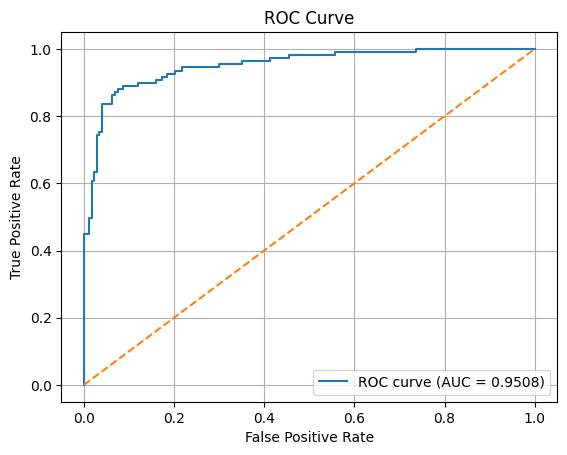

In [20]:
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc

x, y = x_test, Y_test

# Get predicted probabilities for the positive class
y_scores = model.predict(x)  
# If your model doesn't support predict_proba, use:
# y_scores = model.decision_function(X_train)

# Compute ROC curve
fpr, tpr, thresholds = roc_curve(y, y_scores)

# Compute AUC
roc_auc = auc(fpr, tpr)

# Plot
plt.figure()
plt.plot(fpr, tpr, label=f"ROC curve (AUC = {roc_auc:.4f})")
plt.plot([0, 1], [0, 1], linestyle="--")  # random classifier line
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend(loc="lower right")
plt.grid(True)
plt.show()

8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step


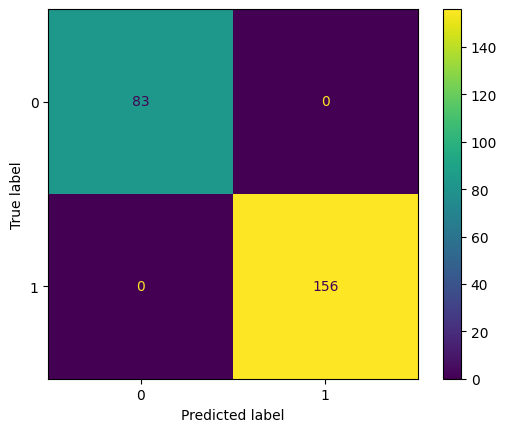

In [13]:
import numpy as np
from sklearn.metrics import ConfusionMatrixDisplay

# id = 4

# idx = np.concatenate((np.where(y_train == 0), np.where(y_train == id)), axis=1)

# x = x_train[idx].squeeze()
# y = y_train[idx].squeeze()

# y = np.where(y==id, 1, y)

# print(x.shape, y.shape)

ConfusionMatrixDisplay.from_predictions(Y_train, np.round(model.predict(x_train)))